In [19]:
%pip install scipy
%pip install statsmodels
%pip install scikit-learn

from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Questão A

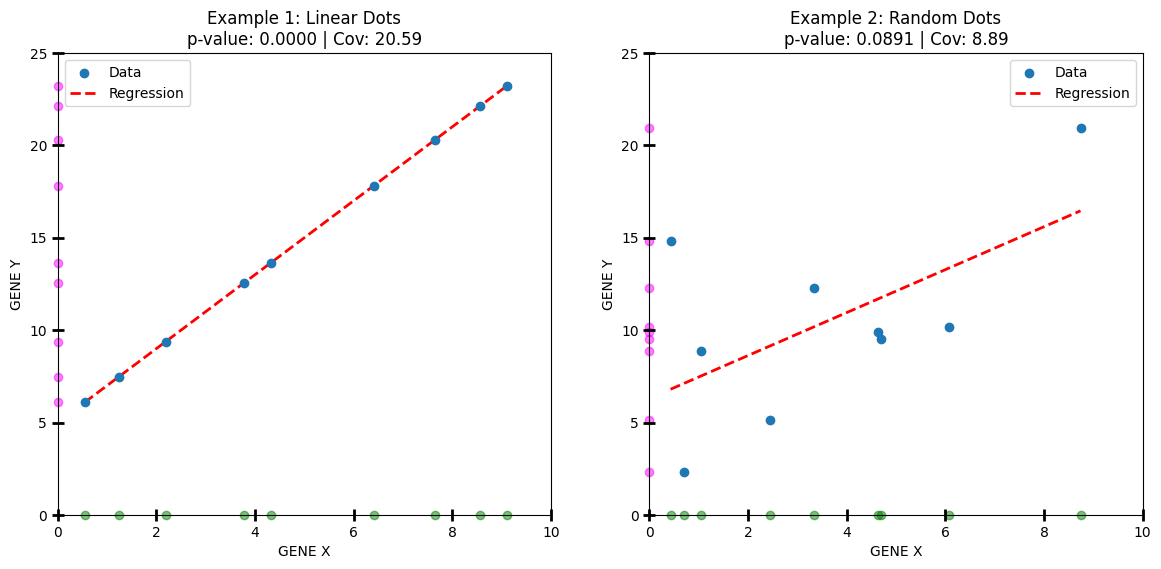

In [20]:
#plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

def processar_grafico(ax, x, y, title):
    #linear regression
    res = stats.linregress(x, y)
    
    #covariance
    cov_matrix = np.cov(x, y)
    cov_val = cov_matrix[0, 1]

    #p value
    p_value = res.pvalue

    #dots and projections
    ax.scatter(x, y, zorder=3, label='Data')
    ax.scatter(x, [0]*len(x), color='green', alpha=0.5, clip_on=False)
    ax.scatter([0]*len(y), y, color='magenta', alpha=0.5, clip_on=False)

    #linear regression line
    lx = np.linspace(min(x), max(x), 100)
    ly = res.slope * lx + res.intercept
    ax.plot(lx, ly, color='red', linestyle='--', linewidth=2, label='Regression')

    #plot config
    ax.set_title(f"{title}\np-value: {p_value:.4f} | Cov: {cov_val:.2f}")

    ax.set_xlabel("GENE X")
    ax.set_ylabel("GENE Y")
    ax.set_xlim(0, 10); ax.set_ylim(0, 25)
    ax.tick_params(direction='inout', length=8, width=2)
    ax.legend()


#FIRST GRAPH
#data [0, 10]
x1 = [1.24, 8.57, 4.32, 0.55, 9.12, 3.78, 6.41, 2.19, 7.65]
y1 = [7.48, 22.14, 13.64, 6.10, 23.24, 12.56, 17.82, 9.38, 20.30]

processar_grafico(ax1, x1, y1, "Example 1: Linear Dots")

#SECOND GRAPH (RANDOM)
#data [0, 10]
x2 = np.random.uniform(0, 10, 9)
y2 = np.random.uniform(0, 25, 9)

processar_grafico(ax2, x2, y2, "Example 2: Random Dots")

# Interpretação dos dados da questão A:

* **Função linregress**:
    * Encontra a reta que melhor representa os dados.

* **P-Value**:
    * **Gráfico 1 (Linear)**: O p-value é 0, ou seja, a relação entre os dados é real e significativa.
    * **Gráfico 2 (Aleatório)**: O p-value normalmente é alto (maior que 0.05), ou seja, a reta é apenas uma coincidência e os dados não têm relação entre si.

* **Covariância**:
    * A covariância mede se os genes (X e Y) variam juntos e em qual direção.
    * Se a covariância estiver mais perto de 0, menor é a relação entre os genes e mais dificíl de prever resultados.

---

# Questão B

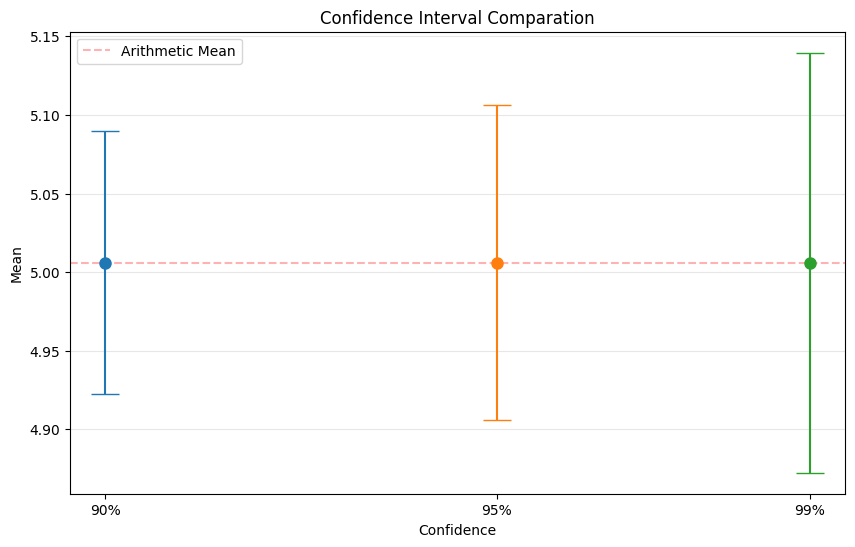

In [21]:
#seed
rng = np.random.default_rng(42)

#data, arithmetic mean and standard deviation
iris = sns.load_dataset('iris')
data = iris[iris['species'] == 'setosa']['sepal_length'].values

arithmetic_mean = np.mean(data)
standard_deviation = np.std(data, ddof=1)

#confidences intervals
n = len(data)
confidences = [0.90, 0.95, 0.99]
intervals = []

for conf in confidences:
    interval = stats.t.interval(conf, df=n-1, loc=arithmetic_mean, scale=stats.sem(data))
    intervals.append(interval)

#error bars
plt.figure(figsize=(10, 6))
for i, (conf, inter) in enumerate(zip(confidences, intervals)):
    error = (inter[1] - inter[0]) / 2
    plt.errorbar(conf, arithmetic_mean, yerr=error, fmt='o', capsize=10,  markersize=8)

#plot config
plt.axhline(arithmetic_mean, color='red', linestyle='--', alpha=0.3, label='Arithmetic Mean')
plt.title('Confidence Interval Comparation')
plt.xlabel('Confidence')
plt.ylabel('Mean')
plt.xticks(confidences, ['90%', '95%', '99%'])
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

---

# Questão C

In [22]:
rng = np.random.default_rng(10)
control = rng.normal(loc=15.2, scale=2.1, size=30)
test = rng.normal(loc=17.5, scale=2.5, size=30)

print(f"Control Mean: {np.mean(control):.2f}")
print(f"Test Mean: {np.mean(test):.2f}")

t_stat, p_value = stats.ttest_ind(control, test)

print(f"T statistic: {t_stat:.6f}")
print(f"P-value: {p_value:.6f}")

Control Mean: 14.63
Test Mean: 17.08
T statistic: -4.927991
P-value: 0.000007


* **Parâmetros:**
    * **Nível de Significância ($\alpha$):** 0,05 (limite de erro aceitável).
    * **P-value obtido:** 0.000007 (probabilidade do resultado ser coincidência).
    * **Estatística t:** -4.9280 (diferença em relação à margem de erro).

* **Análise:**
    O P-value de 0.000007 mostra que a chance de a diferença entre as médias ser coincidência é quase nula. Como este valor é muito menor que o $\alpha$ de 0.05, o resultado é  significativo.
    
* **Hipótese Nula ($H_0$):**
    A Hipótese Nula dizia que não havia diferença real entre o grupo de Controle e o de Teste, mas o valor de t foi de aproximadamente -4.93, ou seja, o resultado está a quase 5 margens de erro de distância do que seria considerado normal. Portanto, nós rejeitamos a Hipótese Nula.
    
* **Conclusão:**
    A análise mostra que o grupo de Teste (média ~17.08) foi melhor que o de Controle (média ~14.63). A diferença é matematicamente comprovada, ou seja, não foi ao acaso.

---

# Questão D

https://docs.google.com/presentation/d/1EHa_fCcUJNSxJFL19yS6Gyrxd6KJajosEasZXwk6DK8/edit?usp=sharing

---

# Questão E

Mean error: 3.80
Mean error interval: [72.1 a 79.7]

Proportion error: 0.046
Proportion error interval: [0.074 a 0.166]


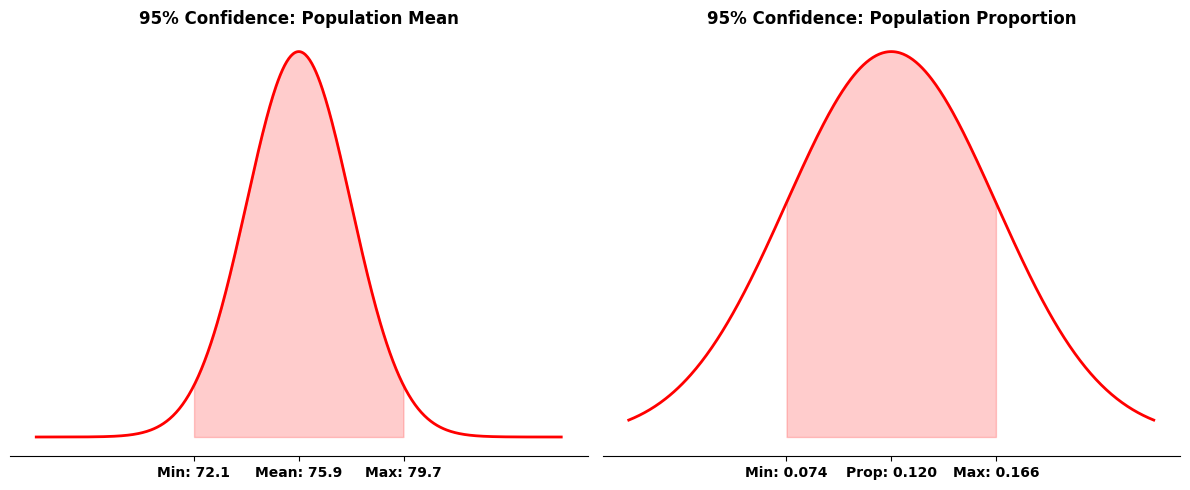

In [23]:
#data
n = 50
df = n - 1
confidence = 0.975

#population mean
mean = 75.9
s = 13.3854 #standard deviation

#calculing t critical
t_critical = stats.t.ppf(confidence, df)

#interval calculation
mean_error = t_critical * (s / math.sqrt(n))

mean_inf_interval = mean - mean_error
mean_sup_interval = mean + mean_error

#population proportion
prop = 0.120

#calculing z critical
z_critical = stats.norm.ppf(confidence)

#interval calculation
prop_error =  (math.sqrt((prop * (1 - prop)) / n))

prop_inf_interval = prop - prop_error
prop_sup_interval = prop + prop_error

#prints
print(f"Mean error: {mean_error:.2f}")
print(f"Mean error interval: [{mean_inf_interval:.1f} a {mean_sup_interval:.1f}]\n")
print(f"Proportion error: {prop_error:.3f}")
print(f"Proportion error interval: [{prop_inf_interval:.3f} a {prop_sup_interval:.3f}]")

#plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

#population mean
x_m = np.linspace(mean - 2.5*mean_error, mean + 2.5*mean_error, 500)
y_m = stats.norm.pdf(x_m, mean, (s / math.sqrt(n)))

ax1.plot(x_m, y_m, color='red', lw=2)
ax1.fill_between(x_m, y_m, where=((x_m >= mean_inf_interval) & (x_m <= mean_sup_interval)), color='red', alpha=0.2)
ax1.set_xticks([mean_inf_interval, mean, mean_sup_interval])
ax1.set_xticklabels([f'Min: {mean_inf_interval:.1f}', f'Mean: {mean:.1f}', f'Max: {mean_sup_interval:.1f}'], fontsize=10, fontweight='bold')
ax1.tick_params(axis='x', labelbottom=True)

ax1.set_title("95% Confidence: Population Mean", fontsize=12, fontweight='bold')
ax1.set_yticks([])
ax1.spines['bottom'].set_visible(True)
for s_name in ['top', 'left', 'right']: ax1.spines[s_name].set_visible(False)

#population proportion
x_p = np.linspace(prop - 2.5*prop_error, prop + 2.5*prop_error, 500)
y_p = stats.norm.pdf(x_p, prop, prop_error)

ax2.plot(x_p, y_p, color='red', lw=2)
ax2.fill_between(x_p, y_p, where=((x_p >= prop_inf_interval) & (x_p <= prop_sup_interval)),  color='red', alpha=0.2)
ax2.set_xticks([prop_inf_interval, prop, prop_sup_interval])
ax2.set_xticklabels([f'Min: {prop_inf_interval:.3f}', f'Prop: {prop:.3f}', f'Max: {prop_sup_interval:.3f}'],  fontsize=10, fontweight='bold')
ax2.tick_params(axis='x', labelbottom=True)
ax2.set_title("95% Confidence: Population Proportion", fontsize=12, fontweight='bold')
ax2.set_yticks([])
ax2.spines['bottom'].set_visible(True)
for s_name in ['top', 'left', 'right']: ax2.spines[s_name].set_visible(False)

#plot
plt.tight_layout()
plt.show()

---

# Questão F

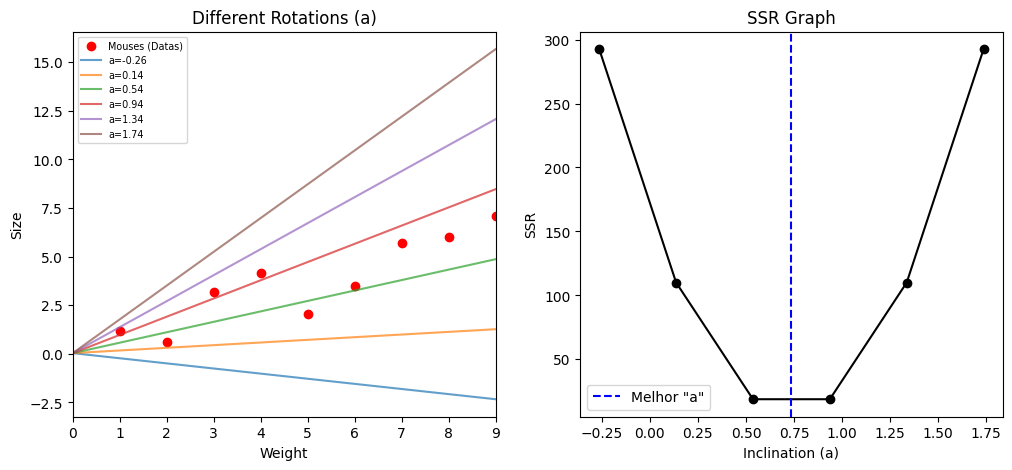

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     30.66
Date:                Sat, 31 Jan 2026   Prob (F-statistic):           0.000871
Time:                        18:11:03   Log-Likelihood:                -11.909
No. Observations:                   9   AIC:                             27.82
Df Residuals:                       7   BIC:                             28.21
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0388      0.749      0.052      0.9

In [24]:
#data
rng = np.random.default_rng(42)
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9]).reshape(-1, 1)
y = 0.1 + 0.78 * x.flatten() + rng.normal(0, 1.0, size=len(x))

#finding b (intercept), and a (inclination)
model = LinearRegression().fit(x, y)
ideal_b = model.intercept_
ideal_a = model.coef_[0]

#statsmodels
x_const = sm.add_constant(x) 
report = sm.OLS(y, x_const).fit()

#trying 6 differents a's
slopes = np.linspace(ideal_a - 1, ideal_a + 1, 6)
ssr_list = []
r2_list = []

#plot
plt.figure(figsize=(12, 5))

#graph 1 - lines 
plt.subplot(1, 2, 1)
plt.scatter(x, y, color='red', label='Mouses (Datas)')

x_plot = np.linspace(0, 9, 100) 
for a in slopes: #lines
    predicted_y_plot = ideal_b + a * x_plot
    plt.plot(x_plot, predicted_y_plot, label=f'a={a:.2f}', alpha=0.7)
    
    predicted_y_calc = ideal_b + a * x.flatten()
    
    ssr_list.append(np.sum((y - predicted_y_calc)**2))
    r2_list.append(r2_score(y, predicted_y_calc))

plt.title("Different Rotations (a)")
plt.xlabel("Weight")
plt.ylabel("Size")
plt.xlim(0, 9)
plt.legend(fontsize='x-small')

#graph 2 - SSR
plt.subplot(1, 2, 2)
plt.plot(slopes, ssr_list, 'o-k')
plt.axvline(ideal_a, color='blue', linestyle='--', label='Melhor "a"')
plt.title("SSR Graph")
plt.xlabel("Inclination (a)")
plt.ylabel("SSR")
plt.legend()
plt.show()

#prints
#ideal model
print(report.summary())

print("\n" + "="*65)
print("Ideal Model Analysis:")
print(f"-> R-squared:         {report.rsquared:.4f}")
print(f"-> Adj. R-squared:    {report.rsquared_adj:.4f}")
print(f"-> F-statistic:       {report.fvalue:.4f}")
print(f"-> Prob (F-statistic):{report.f_pvalue:.4e}")
print(f"-> P-value (Slope a): {report.pvalues[1]:.4e}")
print("="*65)

#A's vs Ideal Model
print("\n" + "="*65)
print(f'{"COMPARISON: ROTATIONS vs. IDEAL (MAX R²)":^65}')
print("="*65)
print(f"{'Inclination (a)':<20} | {'R²':<20} | {'Status'}")
print("-" * 65)

#A's status
melhor_r2 = report.rsquared
for i, a in enumerate(slopes):
    #comparation
    if abs(a - ideal_a) < 0.1:
        status = "CLOSE TO IDEAL"
    else:
        status = "SUB-OPTIMAL"
    
    print(f"{a:<20.4f} | {r2_list[i]:<20.4f} | {status}")

#ideal A
print("-" * 65)
print(f"{ideal_a:<20.4f} | {melhor_r2:<20.4f} | IDEAL (SKLEARN)")
print("="*65)



---

# Questão G

In [25]:
def lu_fatoration(A, b):
    n = len(A)
    A = A.astype(float)
    b = b.astype(float)
    
    #saving the position of each line
    p = np.arange(n)
    
    #loop
    for k in range(n - 1):
        pivot = np.abs(A[k, k]) #diagonal value
        r = k #r is the line k index
        for i in range(k + 1, n):
            if np.abs(A[i, k]) > pivot:
                pivot = np.abs(A[i, k])
                r = i
        
        if pivot == 0:
            return "Singular Matrix"
        
        #inverting lines
        if r != k:
            #changing p
            p[k], p[r] = p[r], p[k]
            
            #changing A
            A[[k, r]] = A[[r, k]]
            print(f"{k+1}º iteration: Inverting the lines {k+1} and {r+1}")
            print(f"Matrix after inverting:\n{A}\n")

        #getting the M's
        for i in range(k + 1, n): #for each value under the diagonal
            m = A[i, k] / A[k, k] #value/diagonal
            A[i, k] = m #saving the m

            for j in range(k + 1, n):
                A[i, j] = A[i, j] - m * A[k, j]

        print(f"Matrix after 'eliminatting' the collumn {k+1}:\n{A}\n")

    #c = Pb
    c = np.zeros(n)
    for i in range(n):
        c[i] = b[p[i]]

    print(f"Vec C: {c}")

    #Ly = c
    y = np.zeros(n)
    for i in range(n):
        sum = 0
        for j in range(i):
            sum += A[i, j] * y[j]

        y[i] = c[i] - sum

    print(f"Vec Y: {y}")

    #Ux = y (solving the system)
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        sum = 0
        for j in range(i + 1, n):
            sum += A[i, j] * x[j]

        x[i] = (y[i] - sum) / A[i, i]
    
    return x

#example 7
A = np.array([
    [3, -4,  1],
    [1,  2,  2],
    [4,  0, -3]])
b = np.array([9, 3, -2])

print(f"Solution: {lu_fatoration(A, b)}")

1º iteration: Inverting the lines 1 and 3
Matrix after inverting:
[[ 4.  0. -3.]
 [ 1.  2.  2.]
 [ 3. -4.  1.]]

Matrix after 'eliminatting' the collumn 1:
[[ 4.    0.   -3.  ]
 [ 0.25  2.    2.75]
 [ 0.75 -4.    3.25]]

2º iteration: Inverting the lines 2 and 3
Matrix after inverting:
[[ 4.    0.   -3.  ]
 [ 0.75 -4.    3.25]
 [ 0.25  2.    2.75]]

Matrix after 'eliminatting' the collumn 2:
[[ 4.     0.    -3.   ]
 [ 0.75  -4.     3.25 ]
 [ 0.25  -0.5    4.375]]

Vec C: [-2.  9.  3.]
Vec Y: [-2.   10.5   8.75]
Solution: [ 1. -1.  2.]


---

# Questão H

In [26]:
def gauss_jacobi(A, b, x0, epsilon, max_iter=100):
    n = len(A)
    A = A.astype(float)
    b = b.astype(float)
    old_x = x0.astype(float)
    
    #calculling alphas
    alphas = []
    for i in range(n):
        non_diagonal_sum = np.sum(np.abs(A[i, :])) - np.abs(A[i, i])
        alphas.append(non_diagonal_sum / np.abs(A[i, i]))
    
    max_alpha = max(alphas)
    print(f"Alphas: {alphas}")
    print(f"Max alpha: {max_alpha}")
    
    if max_alpha < 1:
        print("Guaranteed convergence\n")
    else:
        print("Convergence is not guaranteed\n")

    #loop
    for k in range(1, max_iter + 1):
        new_x = np.zeros_like(old_x) #starting with zeros
        for i in range(n): #fulling the new_x
            sum = b[i] - (np.sum(A[i, :i] * old_x[:i]) + np.sum(A[i, i+1:] * old_x[i+1:])) #b - (sum before diagonal + sum after diagonal)
            new_x[i] = sum / A[i, i] #sum/diagonal
        
        #calculling dr
        absolute_error = np.max(np.abs(new_x - old_x)) #max error between new_x and old_x
        dr = absolute_error / np.max(np.abs(new_x)) #this error/new_x max value
        
        print(f"{k}º iteration: x = {new_x}, dr = {dr:.4f}")
        
        #checking the epsilon
        if dr < epsilon:
            print(f"\nConvergence achieved in iteration {k}")

            return new_x
        
        #new_x is now old_x
        old_x = new_x.copy()

    return old_x

#example 10
A = np.array([[10, 2, 1], 
              [1, 5, 1], 
              [2, 3, 10]])
b = np.array([7, -8, 6])
x0 = np.array([0.7, -1.6, 0.6])
eps = 0.05

print(f"Solution: {gauss_jacobi(A, b, x0, eps)}")

Alphas: [0.3, 0.4, 0.5]
Max alpha: 0.5
Guaranteed convergence

1º iteration: x = [ 0.96 -1.86  0.94], dr = 0.1828
2º iteration: x = [ 0.978 -1.98   0.966], dr = 0.0606
3º iteration: x = [ 0.9994 -1.9888  0.9984], dr = 0.0163

Convergence achieved in iteration 3
Solution: [ 0.9994 -1.9888  0.9984]


---

# Questão I

In [27]:
import numpy as np

def gauss_seidel(A, b, x0, epsilon, max_iter=100):
    n = len(A)
    A = A.astype(float)
    b = b.astype(float)
    new_x = x0.astype(float)
    
    #calculling betas
    betas = np.zeros(n)
    for i in range(n):
        before_diagonal_sum = np.sum(np.abs(A[i, :i]) * betas[:i])
        after_diagonal_sum = np.sum(np.abs(A[i, i+1:]))
        betas[i] = (before_diagonal_sum + after_diagonal_sum) / np.abs(A[i, i])
    
    max_beta = np.max(betas)
    print(f"Betas: {betas}")
    print(f"Max beta: {max_beta:.4f}")
    
    if max_beta < 1:
        print("Guaranteed convergence\n")
    else:
        print("Convergence is not guaranteed\n")

    #loop
    for k in range(1, max_iter + 1):
        old_x = new_x.copy()
        
        for i in range(n):
            sum = b[i] - (np.sum(A[i, :i] * new_x[:i]) + np.sum(A[i, i+1:] * old_x[i+1:]))
            new_x[i] = sum / A[i, i]
        
        #calculating dr
        absolute_error = np.max(np.abs(new_x - old_x))
        dr = absolute_error / np.max(np.abs(new_x))
        
        print(f"{k}º iteration: x = {new_x}, dr = {dr:.4f}")
        
        #checking the epsilon
        if dr < epsilon:
            print(f"\nConvergence achieved in iteration {k}")
            return new_x
            
    return new_x

#example 14
A = np.array([[5, 1, 1], 
              [3, 4, 1], 
              [3, 3, 6]])
b = np.array([5, 6, 0])
x0 = np.array([0, 0, 0])
eps = 0.05

print(f"Solution: {gauss_seidel(A, b, x0, eps)}")

Betas: [0.4   0.55  0.475]
Max beta: 0.5500
Guaranteed convergence

1º iteration: x = [ 1.     0.75  -0.875], dr = 1.0000
2º iteration: x = [ 1.025   0.95   -0.9875], dr = 0.1951
3º iteration: x = [ 1.0075    0.99125  -0.999375], dr = 0.0409

Convergence achieved in iteration 3
Solution: [ 1.0075    0.99125  -0.999375]
